## 1. Instalação

In [21]:
import pandas as pd
import numpy as np

In [22]:
!pip install -qU langchain langchain-huggingface langchain-tavily langgraph sentence-transformers

## 2. API Keys

chaves de acesso

In [23]:
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN')
TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')

print('HF:', HF_TOKEN is not None)
print('Tavily:', TAVILY_API_KEY is not None)

HF: True
Tavily: True


## 3. LLM — Hugging Face

In [24]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id='openai/gpt-oss-120b',
    task='text-generation',
    max_new_tokens=700,
    huggingfacehub_api_token=HF_TOKEN
)

chat_model = ChatHuggingFace(llm=llm)

In [25]:
response = chat_model.invoke('Explique em duas frases o que é escalada esportiva.')
print(response.content)

Escalada esportiva é uma modalidade de escalada onde o praticante sobe rotas fixas em rochas ou paredes artificiais, usando equipamentos de proteção permanentes (ganchos, ancoragens) que já estão instalados ao longo do percurso. O foco está no desempenho físico e técnico, com a segurança garantida por um sistema de travamento automático que impede quedas graves.


## 4. Embeddings



In [26]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

print('Embeddings prontos.')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embeddings prontos.


## 5. Busca Web — Tavily

busca livros na web

In [37]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=8,
    topic='general',
    tavily_api_key=TAVILY_API_KEY
)

## 6. State do LangGraph

In [38]:
from typing import TypedDict

class State(TypedDict):
    question: str
    search_results: list
    answer: str

## 7. Função - pesquisar na web

In [39]:
def search_web(state: State):
    results = web_search.invoke({'query': state['question']})
    return {'search_results': results.get('results', [])}

## 8. Gerando a resposta

In [40]:
def generate_answer(state: State):
    results = state['search_results']

    if not results:
        return {'answer': 'Não encontrei resultados na web para essa pesquisa.'}

    context = '\n\n'.join([
        f"TITLE: {r['title']}\nURL: {r['url']}\nCONTENT: {r['content']}"
        for r in results
    ])

    prompt = f'''Você é um agente especializado em pesquisar livros de escalada na internet.

Pergunta do usuário:
{state['question']}

Resultados encontrados na internet:
{context}

Sua tarefa:
1. Identifique quais resultados realmente mencionam livros de escalada.
2. Informe título, autor se disponível, por que é relevante e a fonte.
3. Se um resultado não for claramente sobre um livro, não o apresente como livro.
4. Não invente título, autor, preço, avaliação ou URL.
5. Se não houver livros relevantes, diga claramente que a busca não encontrou livros suficientes.

Responda em português e cada item como autor , titulo , preco deve estar em topicos'''

    response = chat_model.invoke(prompt)
    return {'answer': response.content}

## 09. Construção dos nodes

In [41]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node('search_web', search_web)
graph_builder.add_node('generate_answer', generate_answer)

graph_builder.add_edge(START, 'search_web')
graph_builder.add_edge('search_web', 'generate_answer')
graph_builder.add_edge('generate_answer', END)

graph = graph_builder.compile()

## 10. Visualização dos nodes

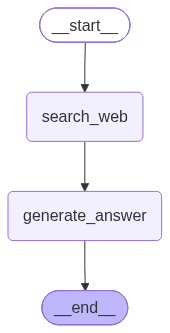

In [42]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 11. Testando o código


In [43]:
question = '''
Sou iniciante em escalada e quero recomendações de livros para melhorar minha técnica.
Quais livros você recomenda?
'''

result = graph.invoke({
    'question': question,
    'search_results': [],
    'answer': ''
})

print(result['answer'])

**Livros de escalada encontrados nos resultados da pesquisa**

---

### 1. **Manual de treinamento para escaladores**  
- **Autor(es):** Irmãos Anderson (não há nome completo nos resultados)  
- **Por que é relevante:** É citado como “um dos melhores guias de treinamento autodidata” e costuma aparecer nas recomendações para quem quer melhorar a performance e a técnica de forma estruturada.  
- **Fonte:** Reddit – thread *“quais são os melhores livros de escalada para melhorar?”*  

---

### 2. **Vamos Escalar!**  
- **Autor(es):** Eny Hertz, Patrícia Duffles e André Costa  
- **Por que é relevante:** O livro é descrito como “descomplicado, vai direto ao assunto” e aborda passo a passo as técnicas de guia de cordada, manejo da corda, nós, ancoragens e demais fundamentos úteis para iniciantes que desejam evoluir de forma segura.  
- **Fonte:** Página “Sugestões de Leitura” do Clube Niteroiense de Montanhismo (CNM)  

---

### 3. **Escale Melhor e com Mais Segurança** (4ª edição atualizad

# Streamlit

In [1]:
!pip install streamlit langchain-openai

In [2]:
%%writefile app.py
import streamlit as st
from langchain_openai.chat_models import ChatOpenAI

st.title("Pesquisa de livros!")

with st.form("book_form"):
    text = st.text_area(
        "Qual tipo de livro você procura?",
    )
    submitted = st.form_submit_button("Search")

    if submitted:
        st.write("Searching the web...")
        st.write(question)

Overwriting app.py


In [3]:
!streamlit run app.py &> /content/streamlit.log &

In [4]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 4s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [5]:
!streamlit run app.py --server.address=0.0.0.0 > /content/streamlit.log 2>&1 &

In [6]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://proud-points-sing.loca.lt
^C
